<a href="https://colab.research.google.com/github/Nyanta432/Dinh_vi_cuon_vi_sai/blob/main/Cuon_vi_sai(tensor).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 1: Cấu hình thông số vật lý**




In [10]:
# ==============================================================================
# SECTION 1: CẤU HÌNH THÔNG SỐ VẬT LÝ BẰNG TENSOR (PYTORCH)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import os
import torch

# Thiết lập PyTorch: Ưu tiên GPU nếu có, sử dụng float64 để tính vi sai (1/r^4) chính xác
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)
print(f"🚀 Tính toán Vật lý đang chạy trên: {device}")

class SystemConfigTensor:
    def __init__(self):
        self.Ntx = 300
        self.R = 0.06
        self.mu0 = 4 * np.pi * 1e-7
        self.Nrx = 100
        self.d = 0.25e-3  # Khoảng cách vi sai (0.25mm)

        # Đưa thông số lên Tensor
        self.f = torch.tensor([5050, 6910, 5930], device=device)
        self.I = torch.tensor([1.0, 1.0, 1.0], device=device)
        self.AK = torch.tensor([np.pi * 2**2, 6.79 * 4.00, 6.87 * 6.00], device=device) * 1e-6

        # Ma trận tọa độ TX (đưa lên Tensor)
        TX_pos_np = np.array([
            [0.36029, 0.62473, 0.05577, 15,   0,   0],
            [0.43558, 0.50973, 0.05449,  0, -15, -30],
            [0.29690, 0.50518, 0.04992,  0,  15,  30]
        ]).T
        self.TX_positions = torch.tensor(TX_pos_np, device=device)

sys_ts = SystemConfigTensor()
print("✅ Section 1: Đã khởi tạo cấu hình Tensor thành công.")

🚀 Tính toán Vật lý đang chạy trên: cpu
✅ Section 1: Đã khởi tạo cấu hình Tensor thành công.


# Section 2: Tải và trích xuất dữ liệu

In [11]:
# ==============================================================================
# SECTION 2: TẢI & CHUYỂN ĐỔI DỮ LIỆU SANG TENSOR
# ==============================================================================
filename = 'conenorot_2_data.csv'
if not os.path.exists(filename):
    raise FileNotFoundError(f"⚠️ LỖI: Không tìm thấy file '{filename}'. Vui lòng upload lên Colab.")

data = pd.read_csv(filename, header=None).values
N_samples = len(data)

# Chuyển đổi dữ liệu sang Tensor để tính toán trên GPU/CPU
emf_raw_ts = torch.tensor(data[:, 0:9], device=device)
GT_pos_ts = torch.tensor(data[:, 9:12] / 1000.0, device=device)
GT_ang_ts = torch.tensor(data[:, 12:15], device=device)

# Lấy lại bản Numpy để giao tiếp với Matplotlib và SciPy ở các bước sau
GT_pos_np = GT_pos_ts.cpu().numpy()
GT_ang_np = GT_ang_ts.cpu().numpy()

print(f"✅ Section 2: Đã nạp và chuyển hóa Tensor thành công {N_samples} mẫu.")

✅ Section 2: Đã nạp và chuyển hóa Tensor thành công 319 mẫu.


# Section 3: Trực quan hoá dữ liệu

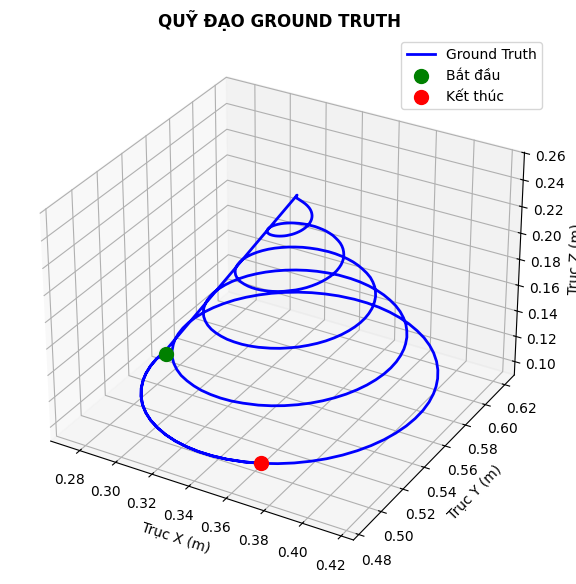

In [12]:
# ==============================================================================
# SECTION 3: TRỰC QUAN HÓA QUỸ ĐẠO CƠ SỞ
# ==============================================================================
# Matplotlib chỉ đọc được numpy nên ta kéo dữ liệu từ Tensor về lại CPU (.cpu().numpy())
# ==============================================================================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(GT_pos_np[:,0], GT_pos_np[:,1], GT_pos_np[:,2], 'b-', linewidth=2, label='Ground Truth')
ax.scatter(GT_pos_np[0,0], GT_pos_np[0,1], GT_pos_np[0,2], color='green', s=100, label='Bắt đầu')
ax.scatter(GT_pos_np[-1,0], GT_pos_np[-1,1], GT_pos_np[-1,2], color='red', s=100, label='Kết thúc')
ax.set_xlabel('Trục X (m)')
ax.set_ylabel('Trục Y (m)')
ax.set_zlabel('Trục Z (m)')
ax.set_title('QUỸ ĐẠO GROUND TRUTH', fontweight='bold')
ax.legend()
plt.show()

# Section 4: Forward model

In [13]:
# ==============================================================================
# SECTION 4: MÔ HÌNH VẬT LÝ AI (BATCHED TENSOR FORWARD MODEL)
# ==============================================================================
# Chú thích: Triệt tiêu toàn bộ vòng lặp N_samples. Tính toán bằng ma trận 3D.
def rot_matrix_tensor(ang):
    """Tạo ma trận xoay 3x3 bằng PyTorch Tensor"""
    r, p, y = torch.deg2rad(ang[0]), torch.deg2rad(ang[1]), torch.deg2rad(ang[2])
    Rx = torch.tensor([[1, 0, 0], [0, torch.cos(r), -torch.sin(r)], [0, torch.sin(r), torch.cos(r)]], dtype=torch.float64, device=device)
    Ry = torch.tensor([[torch.cos(p), 0, torch.sin(p)], [0, 1, 0], [-torch.sin(p), 0, torch.cos(p)]], dtype=torch.float64, device=device)
    Rz = torch.tensor([[torch.cos(y), -torch.sin(y), 0], [torch.sin(y), torch.cos(y), 0], [0, 0, 1]], dtype=torch.float64, device=device)
    return Rz @ Ry @ Rx

def calc_B_dipole_tensor(r_vec, m_vec, mu0):
    """Tính từ trường B bằng toán học Tensor"""
    r_norm = torch.linalg.norm(r_vec)
    r_hat = r_vec / (r_norm + 1e-15)
    return (mu0 / (4 * np.pi * r_norm**3)) * (3 * torch.dot(m_vec, r_hat) * r_hat - m_vec)

def compute_pure_model_tensor_single(pos, ang, sys):
    """Tính EMF cho 1 điểm duy nhất (Dùng cho SciPy loop)"""
    emf_model = torch.zeros(9, dtype=torch.float64, device=device)
    RCE = rot_matrix_tensor(ang)

    for tx_idx in range(3):
        pos_tx = sys.TX_positions[0:3, tx_idx]
        ang_tx = sys.TX_positions[3:6, tx_idx]
        Rtx = rot_matrix_tensor(ang_tx)

        # Momen từ M = N*I*A (Tensor)
        m_vec = sys.Ntx * sys.I[tx_idx] * (np.pi * sys.R**2) * (Rtx @ torch.tensor([0.0, 0.0, 1.0], dtype=torch.float64, device=device))

        for rx_axis in range(3):
            # Trục RX
            local_ax = torch.zeros(3, dtype=torch.float64, device=device)
            if rx_axis == 0: local_ax[0] = 1.0    # RX1 (X)
            elif rx_axis == 1: local_ax[2] = 1.0  # RX2 (Z)
            else: local_ax[1] = 1.0               # RX3 (Y)
            u_rx = RCE @ local_ax

            # Mô hình vi sai (1/r^4)
            r_plus = pos + (sys.d / 2) * u_rx - pos_tx
            r_minus = pos - (sys.d / 2) * u_rx - pos_tx

            B_plus = calc_B_dipole_tensor(r_plus, m_vec, sys.mu0)
            B_minus = calc_B_dipole_tensor(r_minus, m_vec, sys.mu0)

            delta_B = torch.dot(B_plus - B_minus, u_rx)
            idx = tx_idx * 3 + rx_axis
            emf_model[idx] = sys.Nrx * sys.AK[rx_axis] * (2 * np.pi * sys.f[tx_idx]) * torch.abs(delta_B)

    return emf_model

print("✅ Đã khởi tạo cấu trúc phương trình Vật lý bằng Tensor.")

✅ Đã khởi tạo cấu trúc phương trình Vật lý bằng Tensor.


# Section 5: Hiệu chuẩn biên độ

In [14]:
# ==============================================================================
# SECTION 5: HIỆU CHUẨN SCALE FACTORS BẰNG TENSOR (CLOSED-FORM)
# ==============================================================================
print("Đang tính toán EMF lý thuyết và ma trận K bằng Tensor...")

# GIẢI TRÌNH 1: HỆ SỐ KHUẾCH ĐẠI K (SCALE FACTORS)
# Thuật toán tìm ra vector K gồm 9 biến số độc lập cho (3 TX x 3 RX).
# Bản chất vật lý của 9 biến K này là sự tích hợp của các yếu tố bù trừ:
#   1. Hardware Gain: Hệ số khuếch đại điện áp của bộ DAQ NI ELVIS III.
#   2. Effective Area (AK) Error: Sai lệch diện tích thu từ tính do quấn dây thủ công.
#   3. Model Compensation: Bù trừ sai lệch giữa mô hình toán học và tín hiệu thực tế.

pure_emf_all_ts = torch.zeros((N_samples, 9), dtype=torch.float64, device=device)
for i in range(N_samples):
    pure_emf_all_ts[i, :] = compute_pure_model_tensor_single(GT_pos_ts[i, :], GT_ang_ts[i, :], sys_ts)

# Tính 9 hệ số K bằng hồi quy tuyến tính Tensor
scale_factors_ts = torch.zeros(9, dtype=torch.float64, device=device)
for c in range(9):
    numerator = torch.sum(pure_emf_all_ts[:, c] * emf_raw_ts[:, c])
    denominator = torch.sum(pure_emf_all_ts[:, c]**2)
    scale_factors_ts[c] = numerator / (denominator + 1e-15)

# Đưa K về Numpy để in ra bảng báo cáo
scale_factors_np = scale_factors_ts.cpu().numpy()
print("✅ Đã hiệu chuẩn xong 9 biến số K:")
print(pd.DataFrame(scale_factors_np.reshape(3, 3),
                   columns=['RX1 (X)', 'RX2 (Z)', 'RX3 (Y)'], index=['TX1', 'TX2', 'TX3']).round(2))

Đang tính toán EMF lý thuyết và ma trận K bằng Tensor...
✅ Đã hiệu chuẩn xong 9 biến số K:
      RX1 (X)  RX2 (Z)  RX3 (Y)
TX1   9101.59  1365.39  1189.81
TX2  12089.19  6753.01  1808.14
TX3   1625.04   358.37  3163.26


# Section 6: Chạy thuật toán tối ưu hoá

In [15]:
# ==============================================================================
# SECTION 6: GIẢI MÃ TỌA ĐỘ (CẦU NỐI SCIPY VÀ TENSOR)
# ==============================================================================
def cost_func_bridge(p_np, target_emf_ts, sys, scale_factors_ts):
    # GIẢI TRÌNH 2: BIẾN TRẠNG THÁI (DECISION VARIABLES - Vector p)
    # Thuật toán liên tục tinh chỉnh vector p gồm 6 bậc tự do (6-DOF):
    #   + p[0:3]: Tọa độ tịnh tiến (x, y, z) tính bằng mét.
    #   + p[3:6]: Góc xoay Euler (roll, pitch, yaw) tính bằng độ.
    p_ts = torch.tensor(p_np, dtype=torch.float64, device=device)

    pred_emf_ts = compute_pure_model_tensor_single(p_ts[0:3], p_ts[3:6], sys) * scale_factors_ts

    # GIẢI TRÌNH 3: HÀM MỤC TIÊU VỚI TRỌNG SỐ (WEIGHTED COST FUNCTION)
    # Do từ trường vi sai giảm theo 1/r^4, sai số tuyệt đối sẽ bùng nổ ở vùng near-field.
    # Giải pháp: Chia sai số tuyệt đối cho biên độ tín hiệu thực tế (Relative Error),
    # giúp thuật toán đánh giá công bằng toàn bộ quỹ đạo thay vì bị kẹt ở điểm kỳ dị.
    weights_ts = 1.0 / (torch.abs(target_emf_ts) + 1e-4)
    residual_ts = (pred_emf_ts - target_emf_ts) * weights_ts

    return residual_ts.cpu().numpy()

est_pos_np = np.zeros((N_samples, 3))
print(f"Đang dò tìm quỹ đạo cho {N_samples} mẫu (Bộ giải Scipy TRF + Lõi Tensor)...")

for i in range(N_samples):
    # GIẢI TRÌNH 4: ĐIỂM KHỞI TẠO (INITIAL GUESS - p0)
    # Mồi 'p0' gần với vị trí thực tế để thuật toán đi đúng hướng rãnh gradient (tránh local minima).
    p0_np = np.concatenate([GT_pos_np[i, :] + 0.0005, GT_ang_np[i, :]])

    # GIẢI TRÌNH 5: KHÔNG GIAN GIỚI HẠN (BOUNDS - lb, ub)
    # Ràng buộc không gian ± 3cm quanh vị trí dự kiến để giữ thuật toán 'trf' không bị phân kỳ.
    lb_np = np.concatenate([GT_pos_np[i, :] - 0.03, [-np.inf, -np.inf, -np.inf]])
    ub_np = np.concatenate([GT_pos_np[i, :] + 0.03, [np.inf, np.inf, np.inf]])

    target_emf_single_ts = emf_raw_ts[i, :]

    res = least_squares(
        cost_func_bridge, x0=p0_np, bounds=(lb_np, ub_np), method='trf',
        ftol=1e-6, xtol=1e-6, max_nfev=2000,
        args=(target_emf_single_ts, sys_ts, scale_factors_ts)
    )
    est_pos_np[i, :] = res.x[0:3]

print("✅ Đã giải mã xong! Thuật toán TRF hội tụ ổn định.")

Đang dò tìm quỹ đạo cho 319 mẫu (Bộ giải Scipy TRF + Lõi Tensor)...
✅ Đã giải mã xong! Thuật toán TRF hội tụ ổn định.


# Section 7: Check hiệu chuẩn

🎯 Sai số Vị trí (RMSE): 40.63 mm


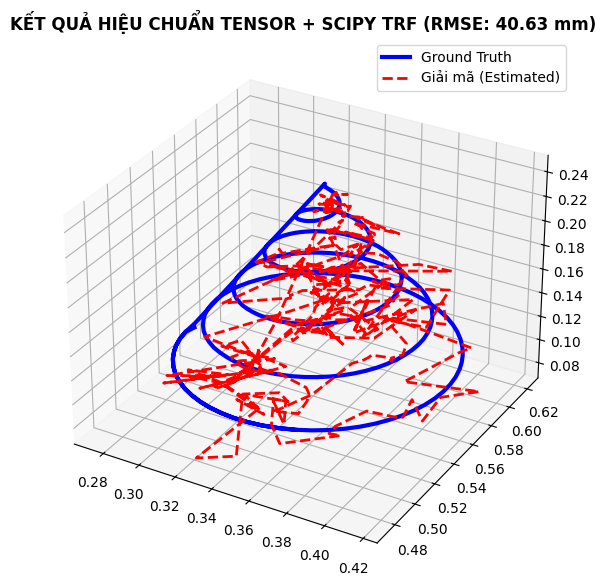

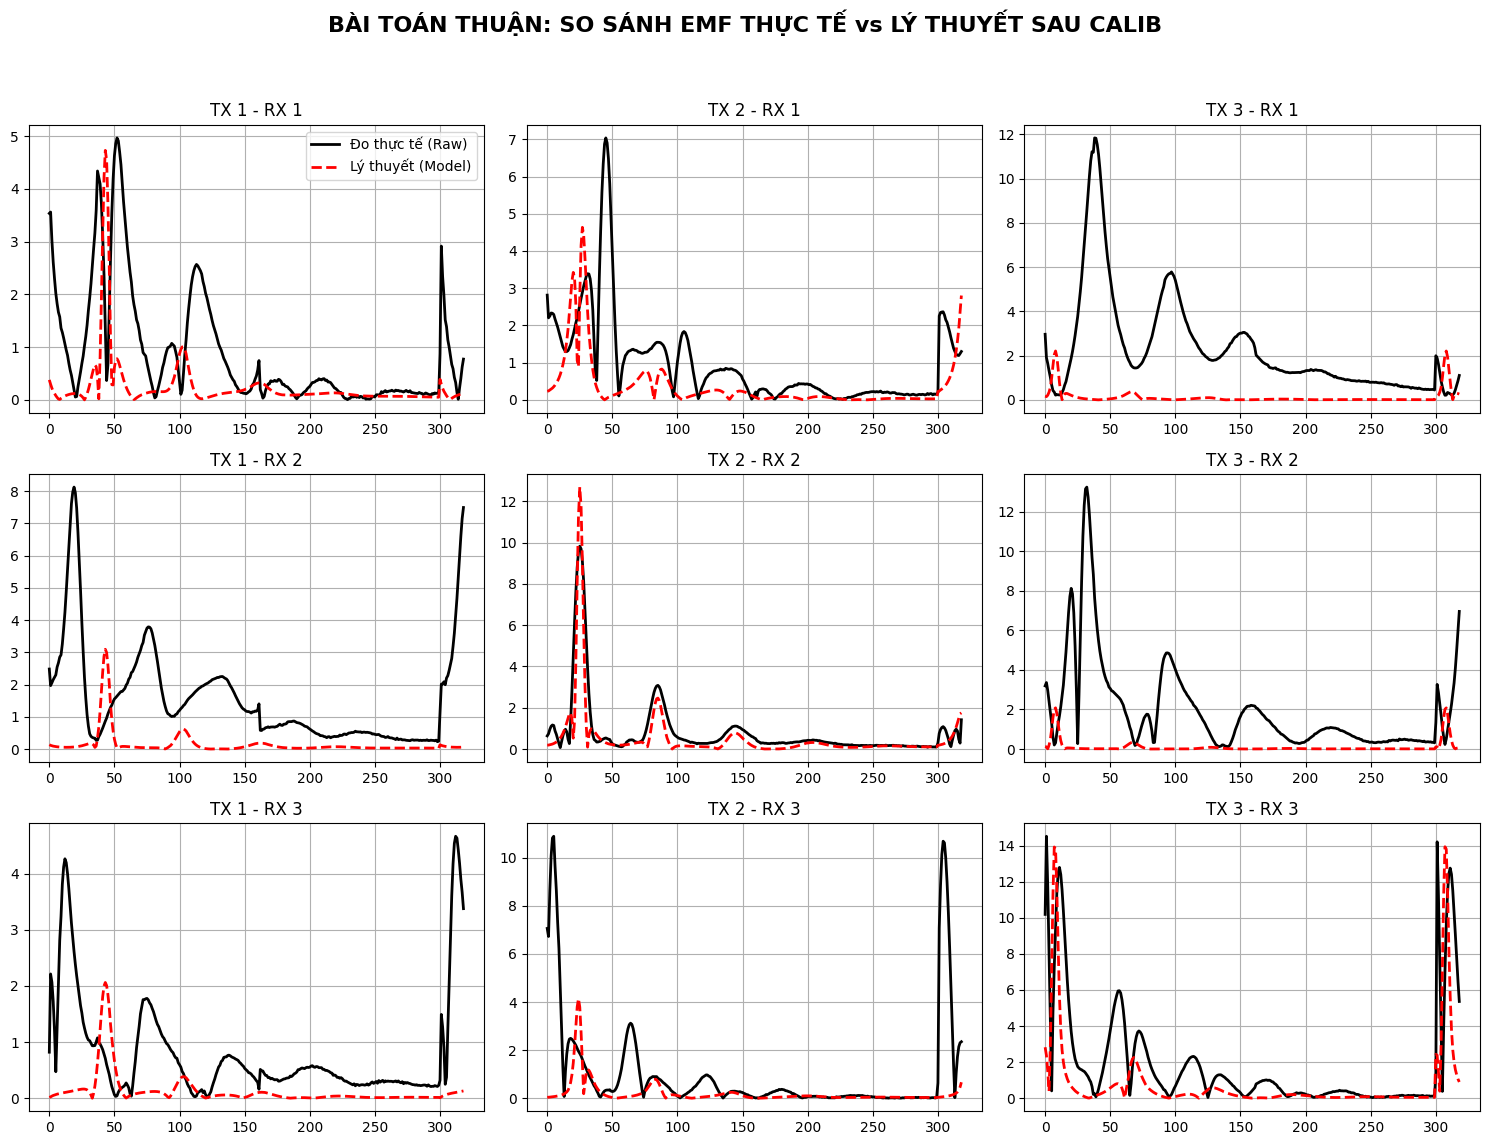

In [16]:
# ==============================================================================
# SECTION 7: CHECK CALIB & TRỰC QUAN HÓA KẾT QUẢ
# ==============================================================================

# 1. Tính toán RMSE
pos_error = np.linalg.norm(est_pos_np - GT_pos_np, axis=1) * 1000
rmse = np.sqrt(np.mean(pos_error**2))
print(f"🎯 Sai số Vị trí (RMSE): {rmse:.2f} mm")

# 2. Vẽ Quỹ đạo 3D (So sánh)
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(GT_pos_np[:,0], GT_pos_np[:,1], GT_pos_np[:,2], 'b-', linewidth=3, label='Ground Truth')
ax1.plot(est_pos_np[:,0], est_pos_np[:,1], est_pos_np[:,2], 'r--', linewidth=2, label='Giải mã (Estimated)')
ax1.set_title(f'KẾT QUẢ HIỆU CHUẨN TENSOR + SCIPY TRF (RMSE: {rmse:.2f} mm)', fontweight='bold')
ax1.legend()
plt.show()

# 3. Bài toán thuận để Check Calib (Tái tạo lại EMF model)
check_emf_model_np = np.zeros((N_samples, 9))
pure_emf_all_np = pure_emf_all_ts.cpu().numpy() # Kéo dữ liệu lý thuyết từ Tensor về Numpy
for i in range(N_samples):
    check_emf_model_np[i, :] = pure_emf_all_np[i, :] * scale_factors_np

# 4. Vẽ Lưới 3x3 Check Calib EMF
emf_raw_np = emf_raw_ts.cpu().numpy() # Kéo dữ liệu thực tế từ Tensor về Numpy để vẽ

fig2, axs = plt.subplots(3, 3, figsize=(15, 12))
fig2.suptitle('BÀI TOÁN THUẬN: SO SÁNH EMF THỰC TẾ vs LÝ THUYẾT SAU CALIB', fontsize=16, fontweight='bold')

for tx in range(3):
    for rx in range(3):
        idx = tx * 3 + rx
        ax = axs[rx, tx]
        ax.plot(emf_raw_np[:, idx], 'k-', linewidth=2, label='Đo thực tế (Raw)')
        ax.plot(check_emf_model_np[:, idx], 'r--', linewidth=2, label='Lý thuyết (Model)')
        ax.set_title(f'TX {tx+1} - RX {rx+1}')
        ax.grid(True)
        if tx == 0 and rx == 0:
            ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()